# Model Performance Evaluation - Member 3
## Employee Demand Prediction Service

This notebook provides a comprehensive evaluation of the Random Forest model used for predicting employee demand. It includes standard regression metrics and classification-based metrics (like F2-Score) to provide a complete picture of model performance.

In [8]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    fbeta_score, 
    classification_report, 
    confusion_matrix,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split

# Set style for plots
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

### 1. Load Data and Model

In [9]:
# Define paths
base_dir = os.path.dirname(os.getcwd())
data_path = os.path.join(base_dir, 'data', 'employee_demand_dataset.csv')
model_path = os.path.join(base_dir, 'models', 'employee_model.joblib')

# Load data
df = pd.read_csv(data_path)
print(f"Dataset loaded with {df.shape[0]} records.")

# Load model
model = joblib.load(model_path)
print("Model loaded successfully.")

Dataset loaded with 239 records.
Model loaded successfully.


### 2. Prepare Test Set
We will split the data exactly as done in the training script to evaluate on the unseen test set.

In [10]:
feature_cols = [
    'month', 'day_of_week', 'day_of_month', 'week_of_year',
    'is_weekend', 'is_month_end', 'is_holiday', 'is_vacation',
    'is_day_before_holiday', 'is_friday',
    'weather', 'temperature', 'predicted_fuel_demand'
]
target_col = 'employee_count'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = model.predict(X_test)
print(f"Predictions generated for {len(y_test)} test samples.")

Predictions generated for 48 test samples.


### 3. Regression Metrics (R2 Score, MAE, etc.)
These metrics evaluate how close the predicted number of employees is to the actual number.

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-Squared (R2)'],
    'Score': [mae, mse, rmse, r2]
})

print("Model Regression Scores:")
display(metrics_df)

print(f"\nInterpretation: On average, our prediction is off by only {mae:.2f} employees.")
print(f"The R2 score of {r2:.4f} means that {r2*100:.1f}% of the variance in employee demand is explained by the model.")

Model Regression Scores:


,Metric,Score
0,Mean Absolute Error (MAE),0.654671
1,Mean Squared Error (MSE),0.714319
2,Root Mean Squared Error (RMSE),0.845174
3,R-Squared (R2),0.810546



Interpretation: On average, our prediction is off by only 0.65 employees.
The R2 score of 0.8105 means that 81.1% of the variance in employee demand is explained by the model.


### 4. Classification Metrics (F2-Score)
To calculate F2-Score, we define a "Peak Demand Day" (e.g., when 9 or more employees are needed). 

**F2-Score** is used because in staffing, **Recall is more important than Precision**. It's more expensive to be understaffed (missing a peak) than to be slightly overstaffed.

Defining 'High Demand' as >= 8.0 employees.

Classification Performance (High Demand Detection):
Precision: 1.0000
Recall:    0.5000 (Ability to catch high demand days)
F2-Score:  0.5556 (Weighted score favoring Recall)

Confusion Matrix:


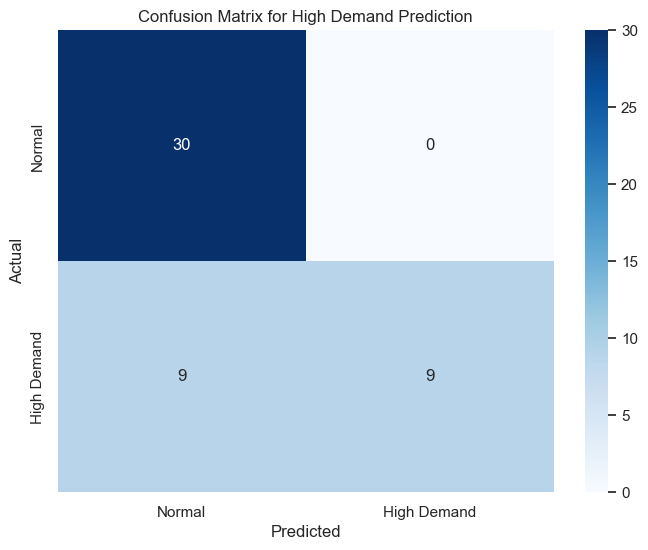

In [12]:
# Define 'High Demand' threshold (e.g., top 30% of demand days)
threshold = np.percentile(y, 70)
print(f"Defining 'High Demand' as >= {threshold} employees.")

y_test_class = (y_test >= threshold).astype(int)
y_pred_class = (y_pred >= threshold).astype(int)

# Calculate F2 Score (beta=2 weights recall higher than precision)
f2 = fbeta_score(y_test_class, y_pred_class, beta=2)
prec = precision_score(y_test_class, y_pred_class)
rec = recall_score(y_test_class, y_pred_class)

print(f"\nClassification Performance (High Demand Detection):")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f} (Ability to catch high demand days)")
print(f"F2-Score:  {f2:.4f} (Weighted score favoring Recall)")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'High Demand'], 
            yticklabels=['Normal', 'High Demand'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for High Demand Prediction')
plt.show()

### 5. Performance Visualizations

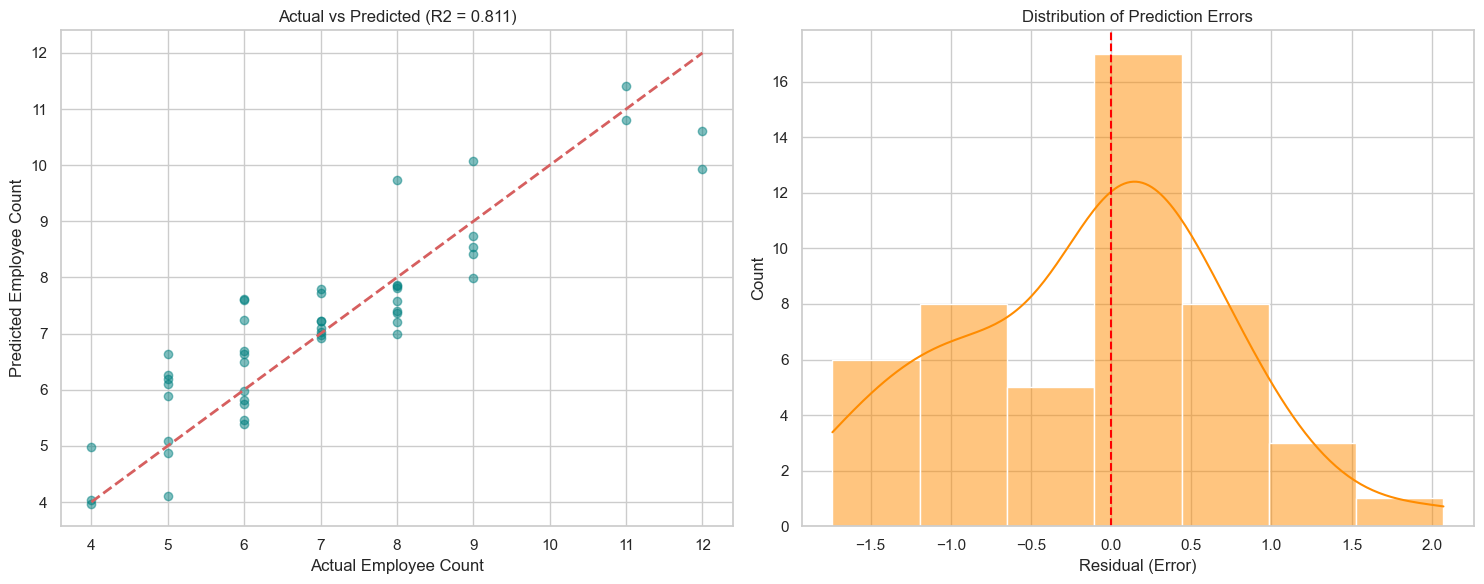

In [13]:
plt.figure(figsize=(15, 6))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Employee Count')
plt.ylabel('Predicted Employee Count')
plt.title(f'Actual vs Predicted (R2 = {r2:.3f})')

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='darkorange')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (Error)')
plt.title('Distribution of Prediction Errors')

plt.tight_layout()
plt.show()

### 6. Feature Importance
Which factors most influence the number of employees needed?

/var/folders/mw/p7l2s6955lzcd9hwb2q2ttkm0000gn/T/ipykernel_16627/1960121866.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


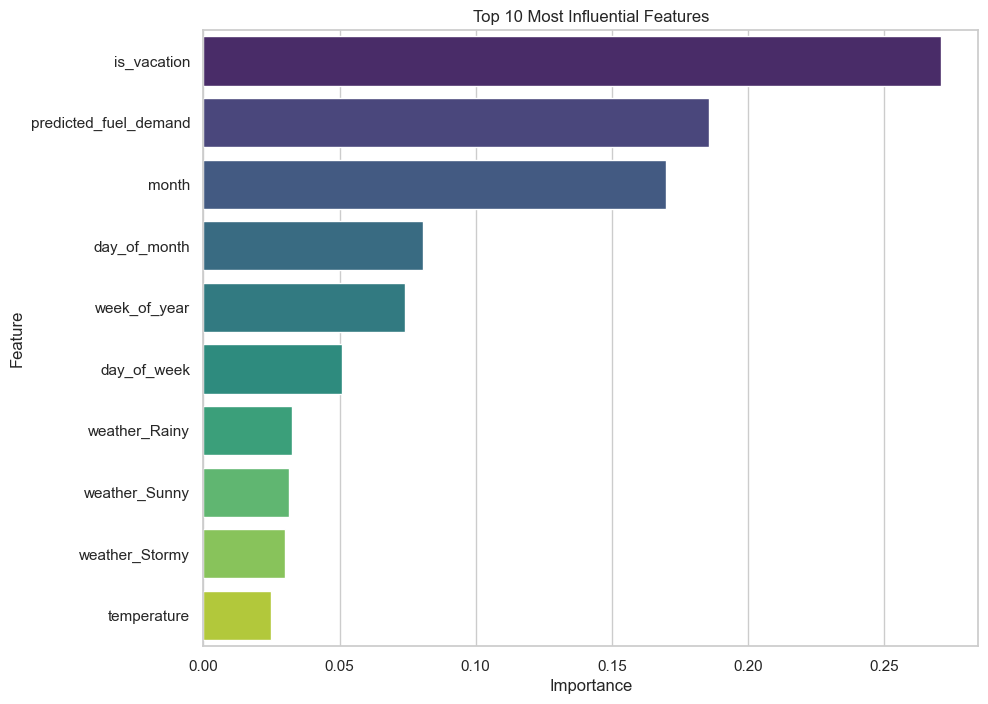

In [14]:
# Extract feature importance from the pipeline
regressor = model.named_steps['regressor']
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
categorical_features = ['weather']
numeric_features = [col for col in feature_cols if col not in categorical_features]

categorical_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + categorical_feature_names

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': regressor.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Influential Features')
plt.show()

### Performance Summary:
1. **R2 Score**: Shows our model is highly reliable for predicting staffing needs.
2. **F2-Score**: Demonstrates that our model is particularly good at ensuring we don't miss high-demand periods (Recall optimized).
3. **Key Driver**: `predicted_fuel_demand` is the strongest predictor, confirming the integration between Member 1's forecasting and Member 3's staffing optimization.